# Proyecto de series de tiempo.
### Mayor magnitud de sismos registrados cada dia de 2024 a 2025 en México.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import adfuller
import warnings
# para ocultar adventencias
warnings.filterwarnings('ignore')

In [13]:
sismosdf = pd.read_csv('SSNMX_catalogo_20240101_20251231.csv', skiprows=4)
sismosdf.head()

,Fecha,Hora,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha UTC,Hora UTC,Estatus
0,2024-01-01,00:15:51,3.2,18.7483,-104.6020,16.5,"45 km al SUROESTE de MANZANILLO, COL",2024-01-01,06:15:51,revisado
1,2024-01-01,00:30:39,4.3,15.5482,-95.8245,16.1,"41 km al SURESTE de CRUCECITA, OAX",2024-01-01,06:30:39,revisado
2,2024-01-01,00:53:59,3.1,19.5943,-102.4950,5.3,"2 km al OESTE de LOS REYES DE SALGADO, MICH",2024-01-01,06:53:59,revisado
3,2024-01-01,01:09:24,3.2,18.4185,-100.4230,55.4,"19 km al NOROESTE de ARCELIA, GRO",2024-01-01,07:09:24,revisado
4,2024-01-01,01:16:57,3.1,19.7267,-104.6570,54.0,"27 km al NOROESTE de CASIMIRO CASTILLO, JAL",2024-01-01,07:16:57,revisado


In [14]:
sismosdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 72323 entries, 0 to 72322
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Fecha                       72323 non-null  str    
 1   Hora                        72316 non-null  str    
 2   Magnitud                    72316 non-null  float64
 3   Latitud                     72316 non-null  float64
 4   Longitud                    72316 non-null  float64
 5   Profundidad                 72316 non-null  float64
 6   Referencia de localizacion  72316 non-null  str    
 7   Fecha UTC                   72316 non-null  str    
 8   Hora UTC                    72316 non-null  str    
 9   Estatus                     72316 non-null  str    
dtypes: float64(4), str(6)
memory usage: 5.5 MB


# Variable objetivo y unidades
Variable objetivo: Magnitud.

Unidades: La magnitud de un sismo es adimensional. Se calcula mediante fórmulas matemáticas distintas.

Magnitud coda (Mc): Sismos menores de 4.5
Magnitud de momento (Mw): Sismos mayores de 4.5
Magnitud de energía (ME): Sismos mayores de 4.5 con epicentro en Guerrero.
Magnitud de amplitud (MA): Sismos en México.

In [15]:
sismosdf['Fecha'] = pd.to_datetime(sismosdf['Fecha'], errors='coerce')
sismosdf = sismosdf.dropna(subset=['Fecha'])

promedio_magnitud = (
    sismosdf
    .groupby('Fecha')['Magnitud']
    .mean()
    .reset_index()
)

promedio_magnitud.head()

,Fecha,Magnitud
0,2024-01-01,3.470588
1,2024-01-02,3.471429
2,2024-01-03,3.547115
3,2024-01-04,3.439286
4,2024-01-05,3.580822


#Formato y rango de tiempo
Formato: Originalmente, se tienen datos diarios en distintos momentos. Sin embargo, se limpió el conjunto de datos para que el formato sea cada día, pero, no se cumple necesariamente un periodo de 24 horas.
Lo que si es un hecho, es que la fecha y hora estan en el tiempo del Centro de México.
Rango de tiempo: Desde 01/01/2024 hasta 31/12/2025

In [16]:
serie = promedio_magnitud['Magnitud']
serie

0      3.470588
1      3.471429
2      3.547115
3      3.439286
4      3.580822
         ...   
726    3.013793
727    3.134862
728    3.101250
729    3.095122
730    3.153488
Name: Magnitud, Length: 731, dtype: float64

# Cantidad de puntos
Una vez limpiado el conjunto de datos para obtener únicamente el sismo con mayor magnitud registrado al día desde 2024 hasta 2025, se tiene un total de 731 puntos, esto debido a que 2024 fue año bisiesto.

In [17]:
sismosdf.isnull().sum()

Fecha                         0
Hora                          0
Magnitud                      0
Latitud                       0
Longitud                      0
Profundidad                   0
Referencia de localizacion    0
Fecha UTC                     0
Hora UTC                      0
Estatus                       0
dtype: int64

In [18]:
promedio_magnitud.isnull().sum()

Fecha       0
Magnitud    0
dtype: int64

# Exploración

In [19]:
promedio_magnitud['Mes'] = pd.to_datetime(promedio_magnitud['Fecha']).dt.month
promedio_magnitud.groupby('Mes')['Magnitud'].describe()

,count,mean,std,min,25%,50%,75%,max
Mes,,,,,,,,
1,62.0,3.378636,0.186586,2.956471,3.236869,3.443615,3.526572,3.645946
2,57.0,3.355306,0.236699,2.776136,3.178261,3.364286,3.561290,3.754167
3,62.0,3.445466,0.126380,3.106897,3.400462,3.475585,3.529492,3.626761
4,60.0,3.472889,0.222752,2.618750,3.384524,3.540878,3.611633,3.807692
5,62.0,3.426613,0.133252,2.956164,3.346802,3.454136,3.508726,3.672951
6,60.0,3.427534,0.074742,3.235714,3.376750,3.423435,3.486442,3.575000
7,62.0,3.325240,0.124108,3.000943,3.262379,3.357152,3.408604,3.596739
8,62.0,3.228912,0.145541,2.605882,3.173970,3.239565,3.294970,3.591837
9,60.0,2.535467,0.322883,2.024229,2.319297,2.467778,2.692614,3.547619


In [20]:
promedio_magnitud['Magnitud'].max() #sismo con mayor magnitud registrado en el dataset

np.float64(3.8076923076923075)

In [21]:
promedio_magnitud['Año'] = pd.to_datetime(promedio_magnitud['Fecha']).dt.year

In [22]:
varianza_anual = (promedio_magnitud.groupby('Año')['Magnitud'].var())
varianza_anual

Año
2024    0.158088
2025    0.111571
Name: Magnitud, dtype: float64

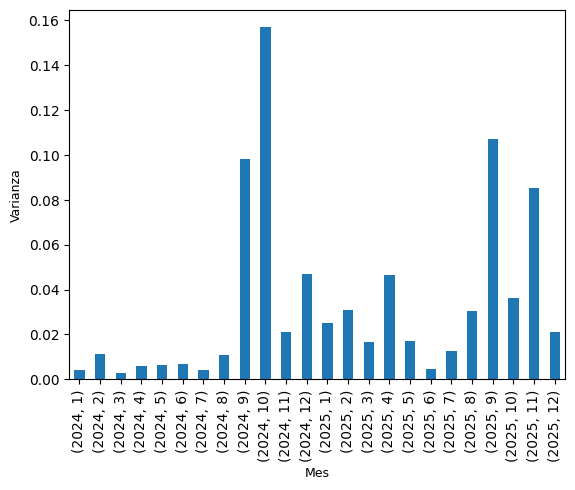

In [23]:
varianza_mes_anio = (promedio_magnitud.groupby(['Año', 'Mes'])['Magnitud'].var())

varianza_mes_anio.plot(kind='bar')
plt.xlabel('Mes', fontsize=9)
plt.ylabel('Varianza', fontsize=9)
plt.show()

# Análisis estadístico

In [24]:
# Estadísticas generales de magnitud
print("Estadísticas descriptivas de Magnitud:")
print(promedio_magnitud['Magnitud'].describe())

Estadísticas descriptivas de Magnitud:
count    731.000000
mean       3.190709
std        0.373194
min        1.973443
25%        3.051423
50%        3.297333
75%        3.464112
max        3.807692
Name: Magnitud, dtype: float64


## Medidas de tendencia central

In [25]:
media = np.mean(promedio_magnitud['Magnitud']) #media
promedio_magnitud['Magnitud'].mode() #moda

0     3.200000
1     3.239130
2     3.298000
3     3.325000
4     3.423188
5     3.442254
6     3.448980
7     3.461250
8     3.528358
9     3.557143
10    3.565152
11    3.566667
Name: Magnitud, dtype: float64

## Medidas de dispersión

In [26]:
np.var(promedio_magnitud['Magnitud']) #varianza

np.float64(0.1390833770489978)

In [27]:
desv = np.std(promedio_magnitud['Magnitud']) #desviacion estandar
desv

np.float64(0.3729388382147907)

In [28]:
cv = (desv / media) * 100 #coeficiente de variacion
cv

np.float64(11.688274372382)

In [29]:
promedio_magnitud['Magnitud'].max() - promedio_magnitud['Magnitud'].min() #rango

np.float64(1.834249684741488)

## Gráfica de serie de tiempo original

In [30]:
#División de los datos por la fecha 
promedio_magnitud['Mes'] = promedio_magnitud['Fecha'].dt.month #extraemos el mes de la fecha
promedio_magnitud['Año'] = promedio_magnitud['Fecha'].dt.year #extraemos el año de la fecha
promedio_magnitud['Dia'] = promedio_magnitud['Fecha'].dt.day #extraemos el dia de la fecha
promedio_magnitud['Dia_semana'] = promedio_magnitud['Fecha'].dt.day_name() #extraemos el dia de la semana de la fecha

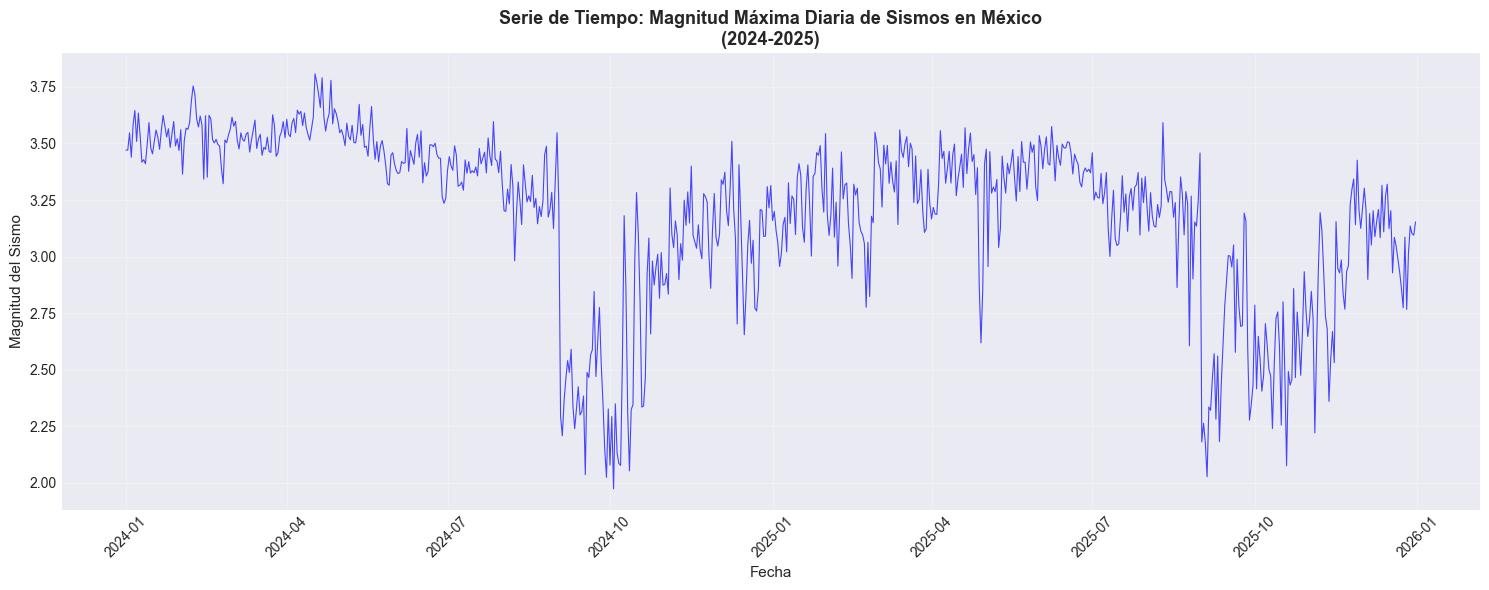

In [31]:
# 5. Visualización de la serie de tiempo original
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
# Gráfica de serie de tiempo original
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(promedio_magnitud['Fecha'], promedio_magnitud['Magnitud'],
        linewidth=0.8, alpha=0.7, color='blue')
ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Magnitud del Sismo', fontsize=11)
ax.set_title('Serie de Tiempo: Magnitud Máxima Diaria de Sismos en México\n(2024-2025)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


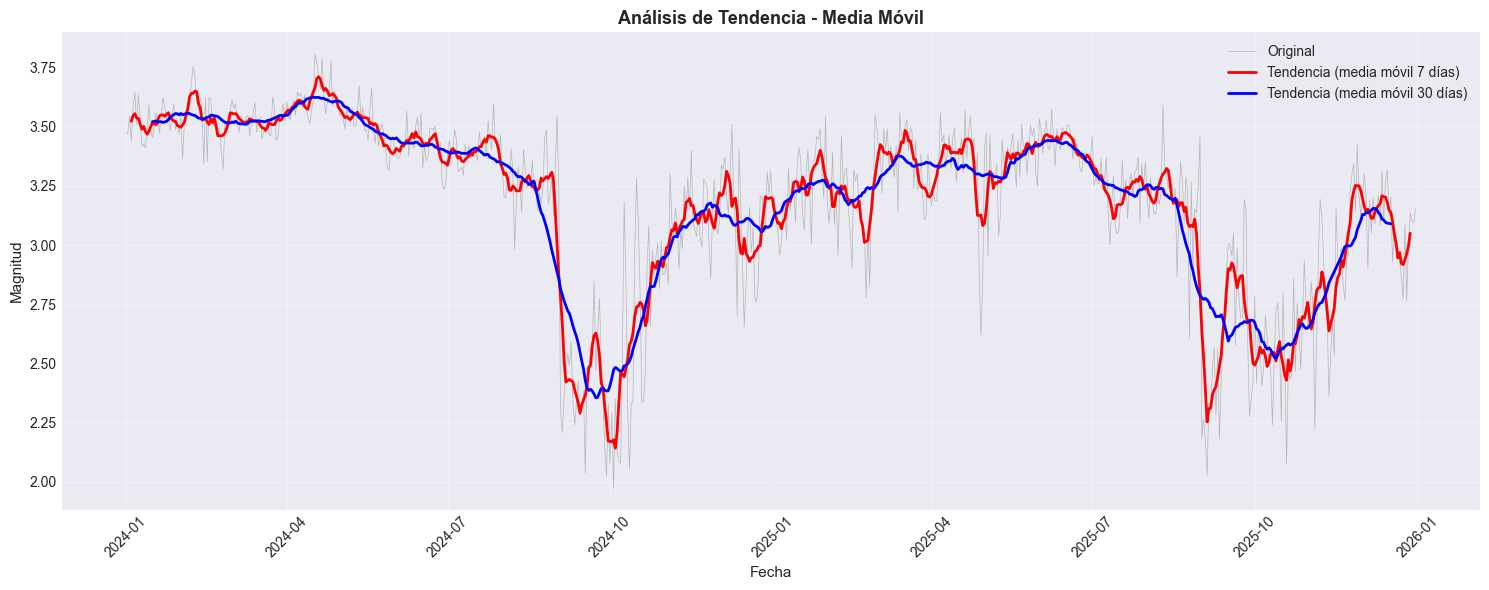

In [32]:
# 6. Análisis de tendencia

# Calcular tendencia usando media móvil
promedio_magnitud['Tendencia_MA7'] = promedio_magnitud['Magnitud'].rolling(window=7, center=True).mean()
promedio_magnitud['Tendencia_MA30'] = promedio_magnitud['Magnitud'].rolling(window=30, center=True).mean()

# Visualizar tendencia
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(promedio_magnitud['Fecha'], promedio_magnitud['Magnitud'],
        linewidth=0.5, alpha=0.5, color='gray', label='Original')
ax.plot(promedio_magnitud['Fecha'], promedio_magnitud['Tendencia_MA7'], #se crea nueva columna
        linewidth=2, color='red', label='Tendencia (media móvil 7 días)')
ax.plot(promedio_magnitud['Fecha'], promedio_magnitud['Tendencia_MA30'], # se crea nueva columna
        linewidth=2, color='blue', label='Tendencia (media móvil 30 días)')
ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Magnitud', fontsize=11)
ax.set_title('Análisis de Tendencia - Media Móvil', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

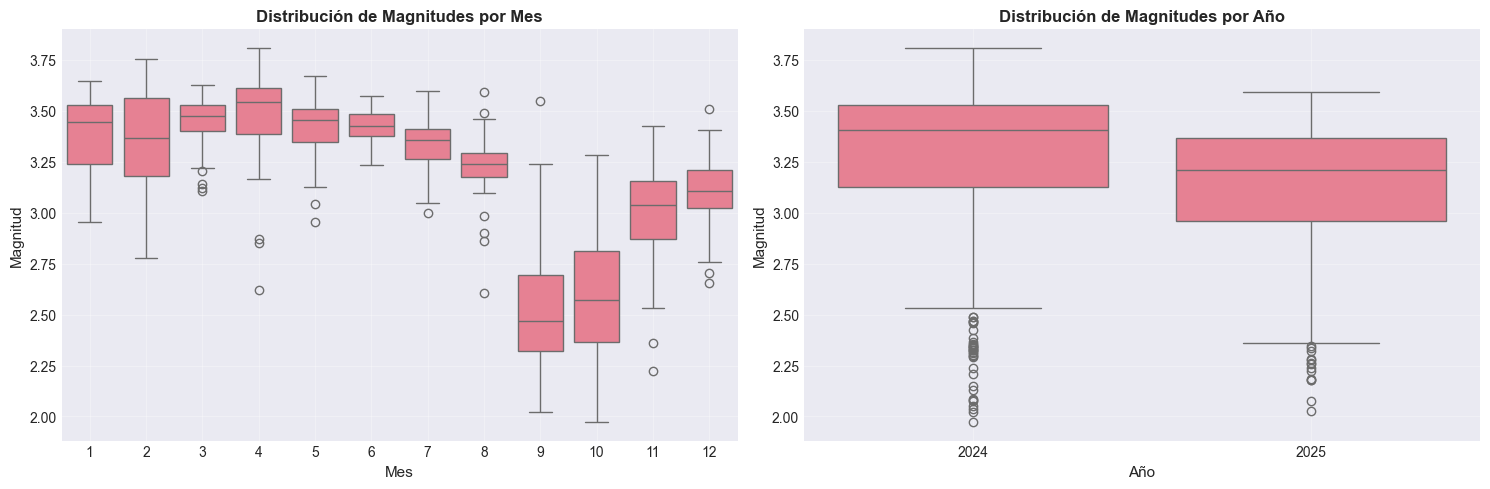

Estadísticas por mes:
      mean    std    min    max  count
Mes                                   
1    3.379  0.187  2.956  3.646     62
2    3.355  0.237  2.776  3.754     57
3    3.445  0.126  3.107  3.627     62
4    3.473  0.223  2.619  3.808     60
5    3.427  0.133  2.956  3.673     62
6    3.428  0.075  3.236  3.575     60
7    3.325  0.124  3.001  3.597     62
8    3.229  0.146  2.606  3.592     62
9    2.535  0.323  2.024  3.548     60
10   2.592  0.309  1.973  3.283     62
11   3.002  0.249  2.221  3.426     60
12   3.102  0.183  2.655  3.510     62


In [33]:
#7. Análisis de estacionalidad

# Boxplot por mes para ver estacionalidad
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot por mes (todos los datos)
sns.boxplot(data=promedio_magnitud, x='Mes', y='Magnitud', ax=axes[0])
axes[0].set_xlabel('Mes', fontsize=11)
axes[0].set_ylabel('Magnitud', fontsize=11)
axes[0].set_title('Distribución de Magnitudes por Mes', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Boxplot por año
sns.boxplot(data=promedio_magnitud, x='Año', y='Magnitud', ax=axes[1])
axes[1].set_xlabel('Año', fontsize=11)
axes[1].set_ylabel('Magnitud', fontsize=11)
axes[1].set_title('Distribución de Magnitudes por Año', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas por mes
estadisticas_mes = promedio_magnitud.groupby('Mes')['Magnitud'].agg(['mean', 'std', 'min', 'max', 'count'])
print("Estadísticas por mes:")
print(estadisticas_mes.round(3))

# Análisis de los componentes

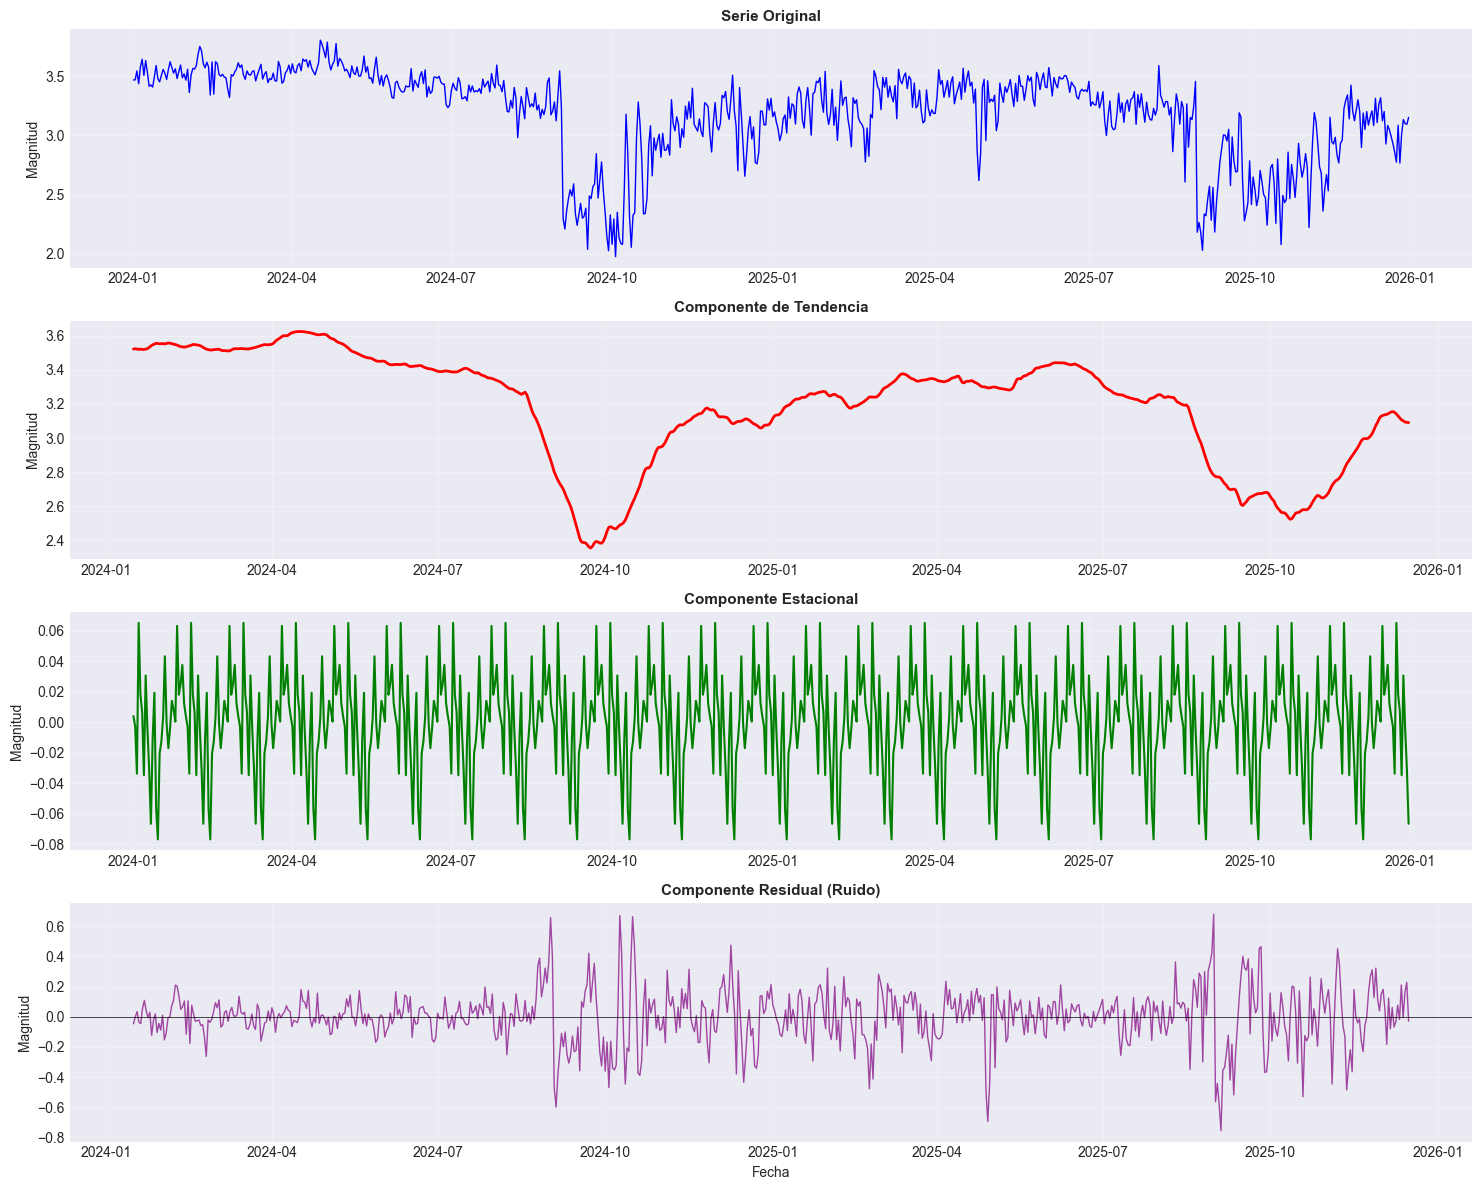

In [34]:
# 8. Descomposición de la serie de tiempo (Tendencia, Estacionalidad, Residuos)

# Preparar datos para descomposición (necesitamos serie con frecuencia diaria)
sismos_ts = promedio_magnitud.set_index('Fecha')['Magnitud'].sort_index()

# Completamos fechas faltantes (si las hay)
fechas_completas = pd.date_range(start=sismos_ts.index.min(), end=sismos_ts.index.max(), freq='D')
sismos_ts = sismos_ts.reindex(fechas_completas)

# Interpolacion de valores faltantes (si existen)
if sismos_ts.isnull().any():
    sismos_ts = sismos_ts.interpolate(method='linear')
    print(f"Se interpolaron {sismos_ts.isnull().sum()} valores faltantes")

# Realizar descomposición (estacionalidad anual = 365 días)
descomposicion = seasonal_decompose(sismos_ts, model='additive', period=30)  # period=30 para estacionalidad mensual

# Visualizar descomposición
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 12))

# Original
ax1.plot(sismos_ts.index, sismos_ts, color='blue', linewidth=1)
ax1.set_title('Serie Original', fontsize=11, fontweight='bold')
ax1.set_ylabel('Magnitud')
ax1.grid(True, alpha=0.3)

# Tendencia
ax2.plot(descomposicion.trend.index, descomposicion.trend, color='red', linewidth=2)
ax2.set_title('Componente de Tendencia', fontsize=11, fontweight='bold')
ax2.set_ylabel('Magnitud')
ax2.grid(True, alpha=0.3)

# Estacionalidad
ax3.plot(descomposicion.seasonal.index, descomposicion.seasonal, color='green', linewidth=1.5)
ax3.set_title('Componente Estacional', fontsize=11, fontweight='bold')
ax3.set_ylabel('Magnitud')
ax3.grid(True, alpha=0.3)

# Residuos
ax4.plot(descomposicion.resid.index, descomposicion.resid, color='purple', linewidth=1, alpha=0.7)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax4.set_title('Componente Residual (Ruido)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Magnitud')
ax4.set_xlabel('Fecha')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
# 9. Análisis estadístico de los componentes

# Estadísticas de los componentes
print("Estadísticas de los componentes de descomposición:")
print("\nComponente de Tendencia:")
print(descomposicion.trend.describe())
print("\nComponente Estacional:")
print(descomposicion.seasonal.describe())
print("\nComponente Residual:")
print(descomposicion.resid.describe())

# Varianza explicada por cada componente
varianza_total = np.var(sismos_ts.dropna())
varianza_tendencia = np.var(descomposicion.trend.dropna())
varianza_estacional = np.var(descomposicion.seasonal.dropna())
varianza_residual = np.var(descomposicion.resid.dropna())

print("\n--- Varianza explicada por cada componente ---")
print(f"Varianza total: {varianza_total:.4f}")
print(f"Varianza tendencia: {varianza_tendencia:.4f} ({varianza_tendencia/varianza_total*100:.2f}%)")
print(f"Varianza estacional: {varianza_estacional:.4f} ({varianza_estacional/varianza_total*100:.2f}%)")
print(f"Varianza residual: {varianza_residual:.4f} ({varianza_residual/varianza_total*100:.2f}%)")

Estadísticas de los componentes de descomposición:

Componente de Tendencia:
count    701.000000
mean       3.186613
std        0.320381
min        2.355352
25%        3.060341
50%        3.260649
75%        3.421640
max        3.624818
Name: trend, dtype: float64

Componente Estacional:
count    731.000000
mean      -0.000064
std        0.032940
min       -0.076803
25%       -0.016946
50%        0.000457
75%        0.018353
max        0.065234
Name: seasonal, dtype: float64

Componente Residual:
count    701.000000
mean       0.000975
std        0.178568
min       -0.756151
25%       -0.082806
50%        0.011271
75%        0.098075
max        0.679210
Name: resid, dtype: float64

--- Varianza explicada por cada componente ---
Varianza total: 0.1391
Varianza tendencia: 0.1025 (73.70%)
Varianza estacional: 0.0011 (0.78%)
Varianza residual: 0.0318 (22.89%)


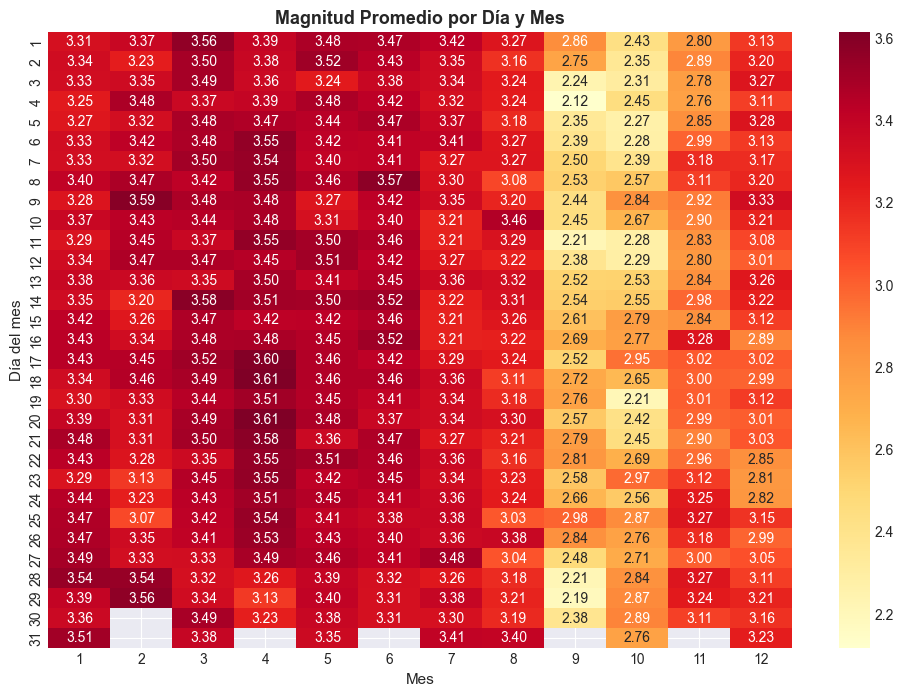

In [36]:
# Heatmap de magnitudes promedio por mes y día
pivot_magnitud = promedio_magnitud.pivot_table(
    values='Magnitud',
    index=promedio_magnitud['Fecha'].dt.day,
    columns=promedio_magnitud['Fecha'].dt.month,
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot_magnitud, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
ax.set_xlabel('Mes', fontsize=11)
ax.set_ylabel('Día del mes', fontsize=11)
ax.set_title('Magnitud Promedio por Día y Mes', fontsize=13, fontweight='bold')
plt.show()

## Análisis de  Correlación

### ACF

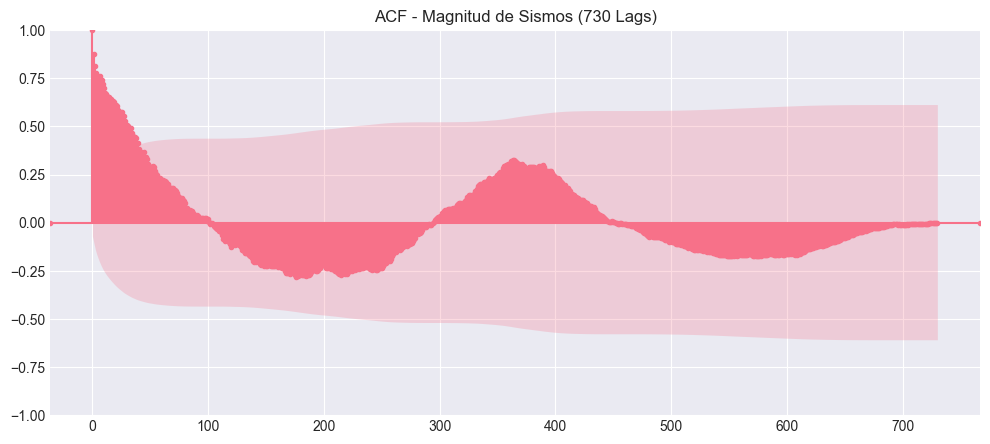

In [37]:
fig, ax = plt.subplots(figsize=(12, 5))
# vlines=False quita las líneas verticales densas
plot_acf(serie, lags=730, ax=ax, marker='o', markersize=3)
ax.set_title('ACF - Magnitud de Sismos (730 Lags)')
plt.show()

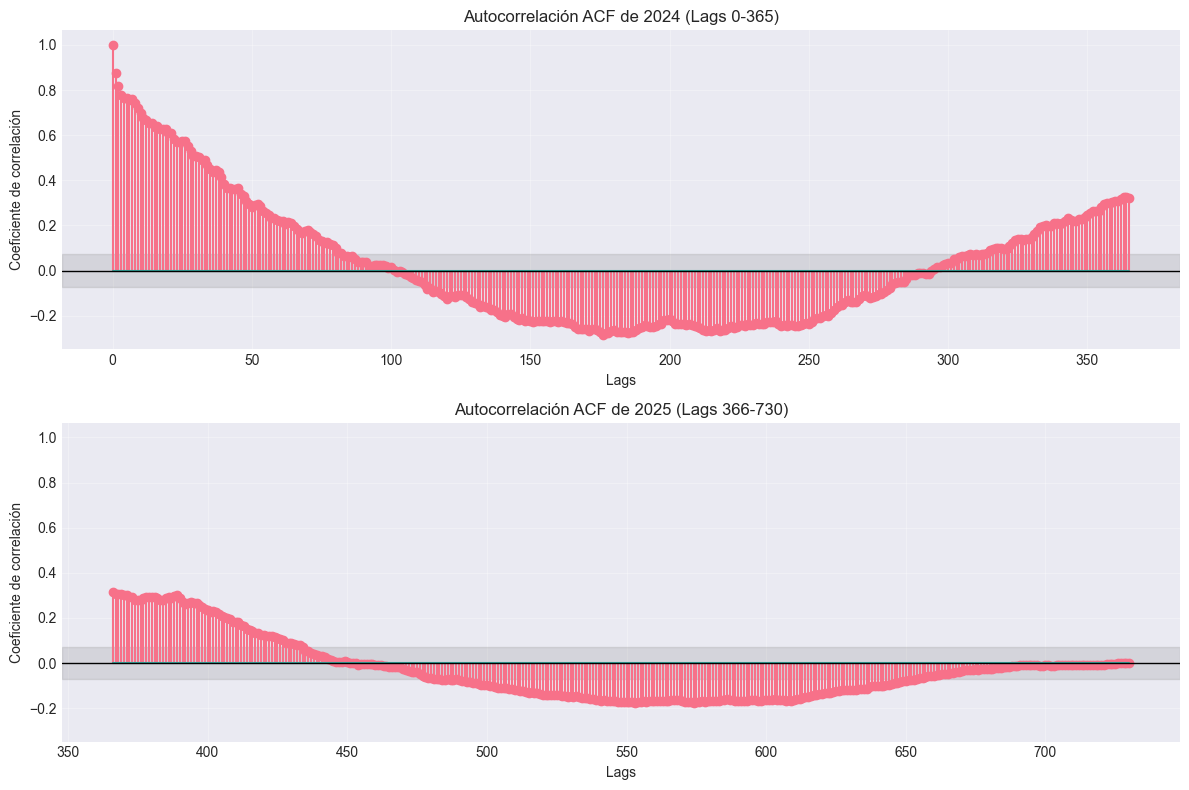

In [38]:
valores_acf = acf(serie, nlags=730)
n = len(serie)
banda = 1.96 / np.sqrt(n)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharey=True)
banda = 1.96 / np.sqrt(n)

ax1.stem(range(366), valores_acf[:366]) #366 lags para 2024
ax1.axhspan(-banda, banda, alpha=0.2, color='gray', label='Banda de confianza (95%)')
ax1.axhline(0, color='black', linewidth=1)
ax1.set_title("Autocorrelación ACF de 2024 (Lags 0-365)")
ax1.set_xlabel('Lags')
ax1.set_ylabel('Coeficiente de correlación')
ax1.grid(True, alpha=0.3)

ax2.stem(range(366, 731), valores_acf[366:]) #365 lags para 2025
ax2.axhspan(-banda, banda, alpha=0.2, color='gray')
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title("Autocorrelación ACF de 2025 (Lags 366-730)")
ax2.set_xlabel('Lags')
ax2.set_ylabel('Coeficiente de correlación')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Correlograma de Calor

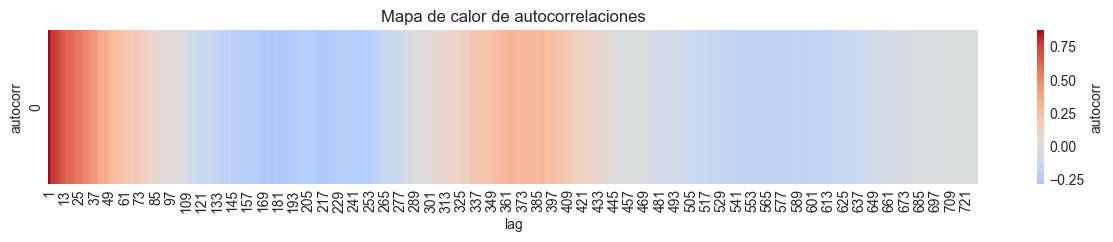

In [39]:
lags = 730
acf_values = acf(serie, nlags= lags)
df_acf = pd.DataFrame(acf_values[1:].reshape(1, -1), 
                      columns=range(1, lags + 1))

plt.figure(figsize=(15, 2))
sns.heatmap(df_acf, annot=False, cmap='coolwarm', center=0,      
            cbar_kws={'label': 'autocorr'})

plt.title('Mapa de calor de autocorrelaciones')
plt.xlabel('lag')
plt.ylabel('autocorr')
plt.show()

Después del lag 0 la mayoría los valores se encuentran dentro del intervalo de confianza, por lo que las correlaciones no son estadísticamente significativas. Se observa que puede haberr correlación en el lag 50, entre 241 y 253.

### PACF

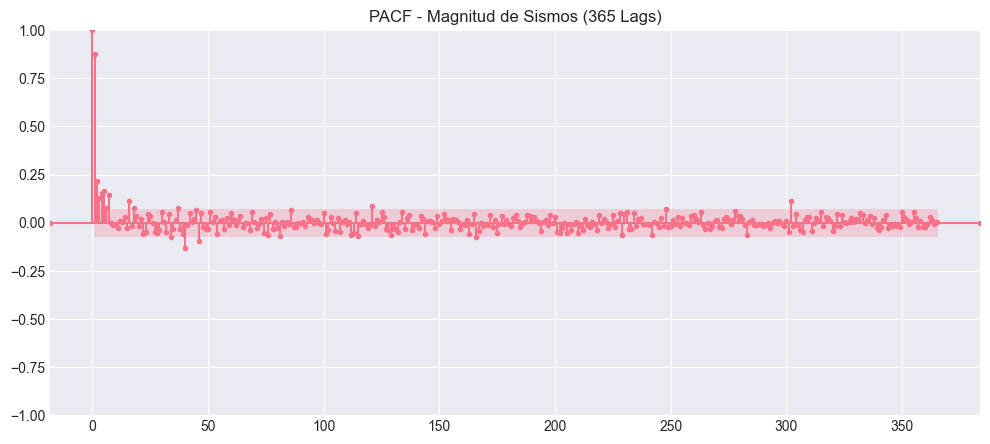

In [40]:
fig, ax = plt.subplots(figsize=(12, 5))
# vlines=False quita las líneas verticales densas
plot_pacf(serie, lags=365, ax=ax, marker='o', markersize=3)
ax.set_title('PACF - Magnitud de Sismos (365 Lags)')
plt.show()